### Carga de Librerías y Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve()
PROJECT_DIR = BASE_DIR.parent
DATA_PROCESSED = PROJECT_DIR / 'data' / 'processed'
file_path = DATA_PROCESSED / 'sp500_features.csv'
df = pd.read_csv(file_path, parse_dates=['Date'],index_col='Date')
df.head()

,Close,Log_Return,Volatility,Extreme_Event
Date,,,,
2010-02-02,1103.319946,0.012890,0.010481,0
2010-02-03,1097.280029,-0.005489,0.010465,0
2010-02-04,1063.109985,-0.031636,0.012390,1
2010-02-05,1066.189941,0.002893,0.012358,0
2010-02-08,1056.739990,-0.008903,0.012323,0


### Modelo GARCH (Volatilidad Dinámica)

A continuación se modelará 
\begin{equation}
\sigma_{t}^2
\end{equation}
en función del pasado usando los valores de la columna **Log_Return**.
GARCH captura mejor los clusters de volatilidad siendo así más realista que Rolling std, esto permitirá alimentar el modelo de riesgo.

In [3]:
# Preparamos los datos
returns = df['Log_Return']*100

In [4]:
# Ajustamos el modelo GARCH
garch = arch_model(returns,vol='Garch',p=1,q=1)
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4816.69
Distribution:                  Normal   AIC:                           9641.39
Method:            Maximum Likelihood   BIC:                           9666.31
                                        No. Observations:                 3753
Date:                Mon, Apr 27 2026   Df Residuals:                     3752
Time:                        15:09:28   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0793  1.232e-02      6.437  1.218e-10 [5.518e-0

Del modelo anterior se obtiene que los parámetros $\alpha = 0.1636$ y $\beta = 0.8039$.  
De lo anterior 
\begin{equation} \alpha + \beta = 0.9675 \end{equation}
donde $\alpha$ representa el impacto de shocks recientes y $\beta$ representa la persistencia de la volatilidad, tal que:
\begin{equation} \alpha + \beta ≈ 1 \end{equation}
Esto significa una alta persistencia de la volatilidad (clustering).

In [5]:
# Obtención de la volatilidad estimada
df['GARCH_Volatility'] = garch_fit.conditional_volatility /100

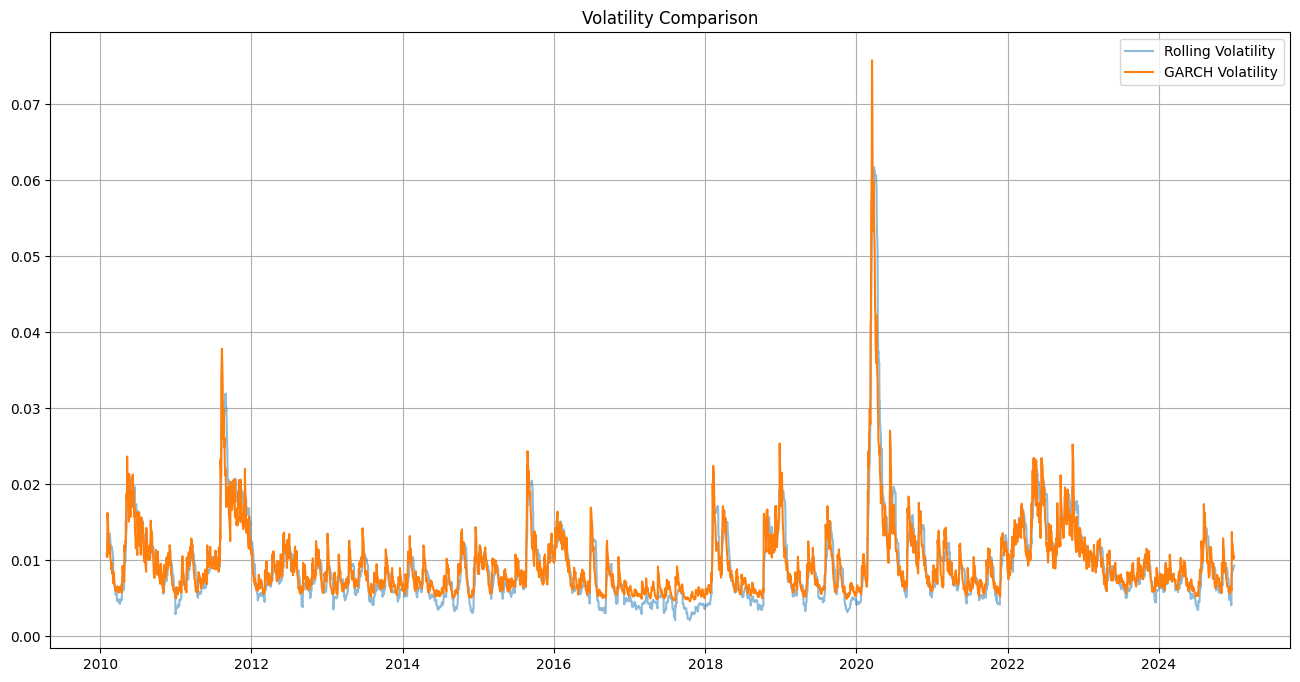

In [6]:
# Visualización 
plt.figure(figsize=(16,8))
plt.plot(df['Volatility'],label='Rolling Volatility',alpha=0.5)
plt.plot(df['GARCH_Volatility'],label='GARCH Volatility')
plt.legend()
plt.title('Volatility Comparison')
plt.grid()
plt.show()

### Modelo de Poisson no Homogéneo

A continuación se pretende modelar a:
\begin{equation}
\lambda(t)
\end{equation}
como una función de la volatilidad antes obtenida.
En particular el valor de $\lambda$ representa la probabilidad de eventos extremos.

In [7]:
# A continuación se obtienen las variables necesarias para los cálculos
X = df[['GARCH_Volatility']]
X = sm.add_constant(X)
y = df['Extreme_Event']

In [8]:
# Ajustamos el modelo 
poisson_model = sm.GLM(y,X,family=sm.families.Poisson())
poisson_results = poisson_model.fit()
print(poisson_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Extreme_Event   No. Observations:                 3753
Model:                            GLM   Df Residuals:                     3751
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -713.33
Date:                Mon, 27 Apr 2026   Deviance:                       1050.7
Time:                        15:09:28   Pearson chi2:                 3.23e+03
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01980
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.6586      0.102  

In [9]:
# Cálculo de intensidad estimada
df['Lambda'] = poisson_results.predict(X)

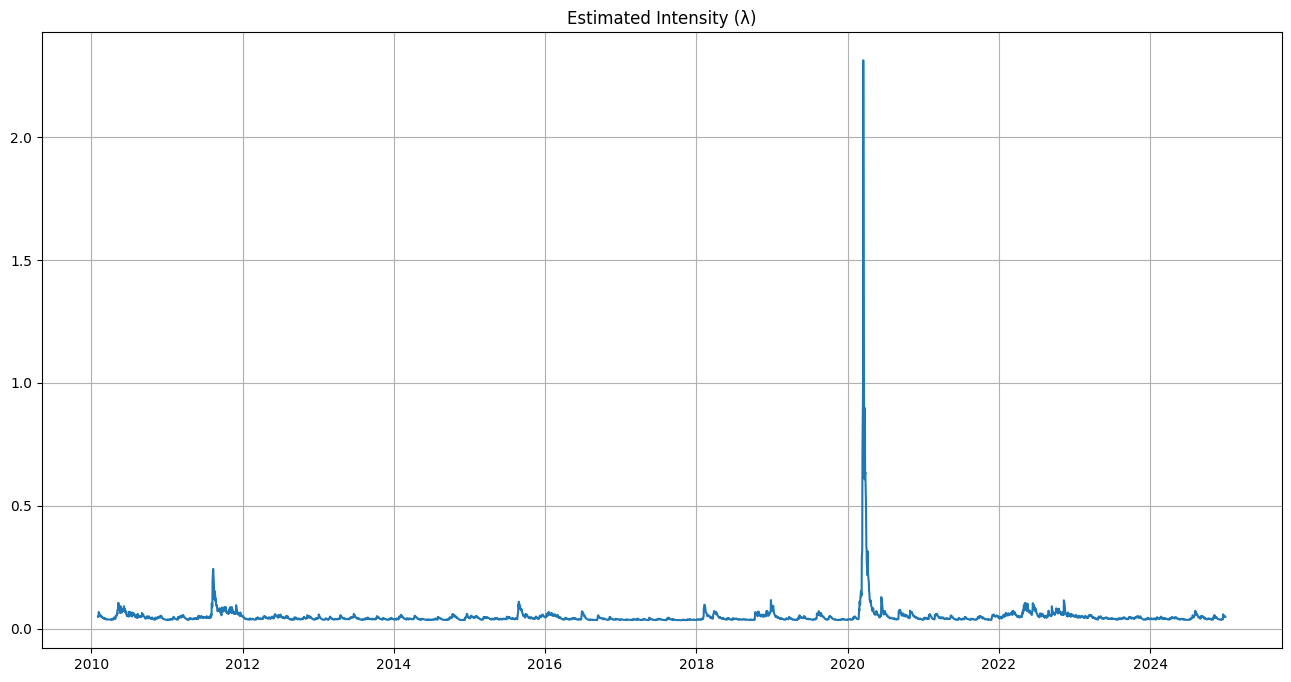

In [10]:
# Visualización
plt.figure(figsize=(16,8))
plt.plot(df['Lambda'])
plt.title('Estimated Intensity (λ)')
plt.grid()
plt.show()

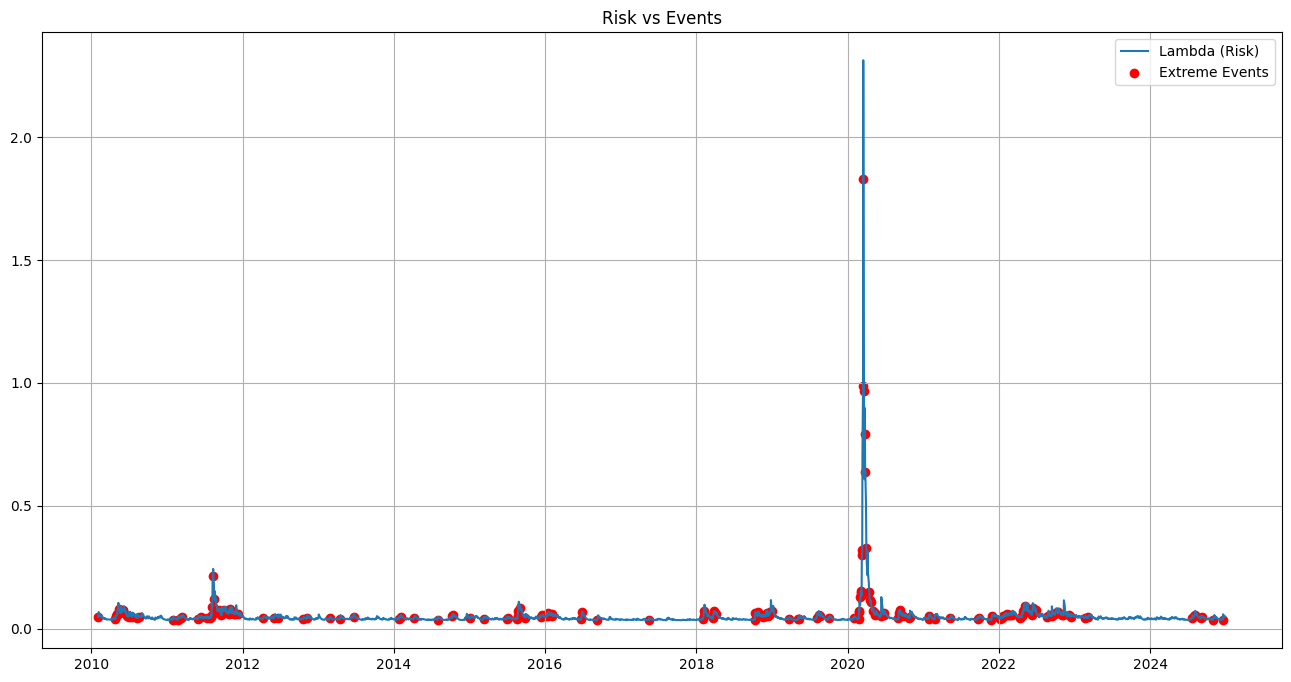

In [11]:
plt.figure(figsize=(16,8))
plt.plot(df['Lambda'],label='Lambda (Risk)')
plt.scatter(
    df.index[df['Extreme_Event']==1],
    df['Lambda'][df['Extreme_Event']==1],
    color='red',
    label='Extreme Events'
)
plt.legend()
plt.title('Risk vs Events')
plt.grid()
plt.show()

### REGÍMENES BASADOS EN LAMBDA

In [12]:
# Percentiles dinámicos
p50 = df['Lambda'].quantile(0.50)
p85 = df['Lambda'].quantile(0.85)

print("\nThresholds de Regímenes:")
print(f"P50: {p50:.4f}")
print(f"P85: {p85:.4f}")

# Función de clasificación
def classify_regime(lambda_value):
    if pd.isna(lambda_value):
        return None
    elif lambda_value < p50:
        return "Stable"
    elif lambda_value < p85:
        return "Moderate"
    else:
        return "High Risk"

# Crear columna categórica
df['Regime'] = df['Lambda'].apply(classify_regime)

# Mapeo numérico (opcional pero recomendado)
regime_map = {
    "Stable": 0,
    "Moderate": 1,
    "High Risk": 2
}

df['Regime_Code'] = df['Regime'].map(regime_map)

# Verificación rápida
print("\nDistribución de Regímenes (%):")
print(df['Regime'].value_counts(normalize=True) * 100)


Thresholds de Regímenes:
P50: 0.0417
P85: 0.0557

Distribución de Regímenes (%):
Regime
Stable       49.986677
Moderate     35.011990
High Risk    15.001332
Name: proportion, dtype: float64


### Guardado de Resultados

In [13]:
output_path = DATA_PROCESSED / 'sp500_model_results.csv'
df.to_csv(output_path)